# **Stacked Charts**

In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.

## Objectives

In this lab, you will perform the following:

- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.

## Setup: Downloading and Loading the Data
**Install the libraries**

In [1]:
#!pip install pandas
#!pip install matplotlib

**Download and Load the Data**

To start, download and load the dataset into a `pandas` DataFrame.

### Step 1: Download the dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

# Load dataset into DataFrame
df = pd.read_csv(file_url)

# Display first 5 rows
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Import necessary libraries and load the dataset

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

### Load the data

In [4]:
df = pd.read_csv(file_url)

### Display the first few rows of the data to understand its structure

In [5]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups

##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups

Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.

In [6]:
# Select required columns

stacked_df = df[
    ['Age', 'JobSatPoints_6', 'JobSatPoints_7']
].dropna()

# Display first few rows
print(stacked_df.head())

                Age  JobSatPoints_6  JobSatPoints_7
1   35-44 years old             0.0             0.0
10  35-44 years old            25.0            10.0
12  35-44 years old            30.0             0.0
15  45-54 years old             0.0             0.0
18  25-34 years old            60.0            10.0


In [7]:
# Convert satisfaction columns to numeric

stacked_df['JobSatPoints_6'] = pd.to_numeric(
    stacked_df['JobSatPoints_6'],
    errors='coerce'
)

stacked_df['JobSatPoints_7'] = pd.to_numeric(
    stacked_df['JobSatPoints_7'],
    errors='coerce'
)

# Remove missing values
stacked_df = stacked_df.dropna()

In [8]:
# Group by Age and calculate median values

age_grouped = (
    stacked_df
    .groupby('Age')[
        ['JobSatPoints_6', 'JobSatPoints_7']
    ]
    .median()
)

print(age_grouped)

                    JobSatPoints_6  JobSatPoints_7
Age                                               
18-24 years old               15.0            20.0
25-34 years old               20.0            15.0
35-44 years old               20.0            15.0
45-54 years old               20.0            15.0
55-64 years old               20.0            20.0
65 years or older             20.0            15.0
Prefer not to say             10.0             7.0
Under 18 years old             1.5             5.0


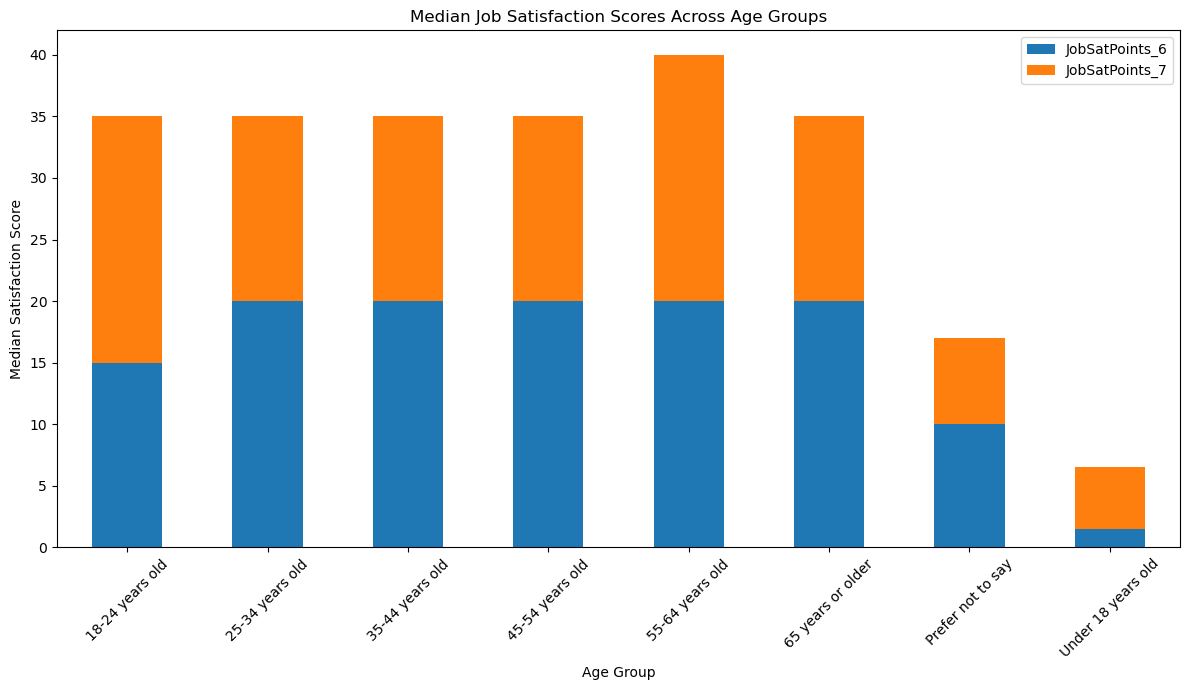

In [9]:
# Create stacked bar chart

age_grouped.plot(
    kind='bar',
    stacked=True,
    figsize=(12,7)
)

plt.title('Median Job Satisfaction Scores Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Median Satisfaction Score')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status

Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.

In [10]:
# Select required columns

employment_df = df[
    ['Employment', 'JobSatPoints_6', 'JobSatPoints_7']
].dropna()

# Display first few rows
print(employment_df.head())

             Employment  JobSatPoints_6  JobSatPoints_7
1   Employed, full-time             0.0             0.0
10  Employed, full-time            25.0            10.0
12  Employed, full-time            30.0             0.0
15  Employed, full-time             0.0             0.0
18  Employed, full-time            60.0            10.0


In [11]:
# Convert satisfaction columns to numeric

employment_df['JobSatPoints_6'] = pd.to_numeric(
    employment_df['JobSatPoints_6'],
    errors='coerce'
)

employment_df['JobSatPoints_7'] = pd.to_numeric(
    employment_df['JobSatPoints_7'],
    errors='coerce'
)

# Remove missing values
employment_df = employment_df.dropna()

In [12]:
# Group by Employment and calculate median values

employment_grouped = (
    employment_df
    .groupby('Employment')[
        ['JobSatPoints_6', 'JobSatPoints_7']
    ]
    .median()
)

# Select top 10 employment types for readability

employment_grouped = employment_grouped.head(10)

print(employment_grouped)

                                                    JobSatPoints_6  \
Employment                                                           
Employed, full-time                                           20.0   
Employed, full-time;Employed, part-time                       15.0   
Employed, full-time;Independent contractor, fre...            15.0   
Employed, full-time;Independent contractor, fre...            20.0   
Employed, full-time;Independent contractor, fre...             7.5   
Employed, full-time;Independent contractor, fre...            20.0   
Employed, full-time;Independent contractor, fre...            18.0   
Employed, full-time;Independent contractor, fre...            20.0   
Employed, full-time;Not employed, and not looki...             0.0   
Employed, full-time;Not employed, but looking f...            15.0   

                                                    JobSatPoints_7  
Employment                                                          
Employed, full-time  

C:\Users\chavi\AppData\Local\Temp\ipykernel_16052\2325020553.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


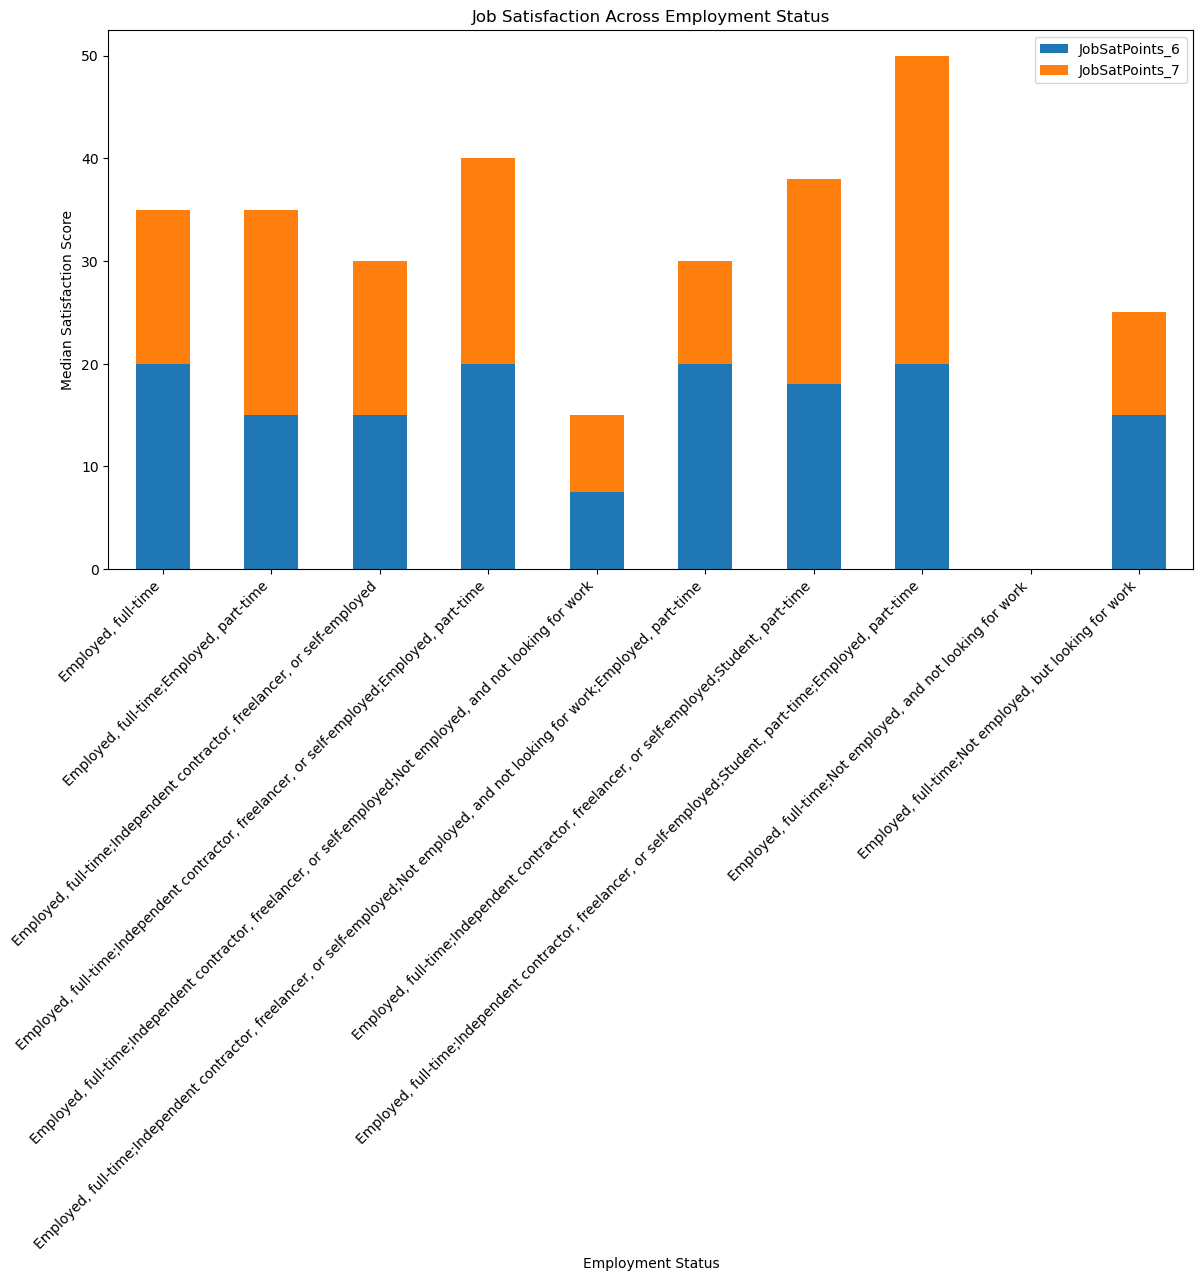

In [13]:
# Create stacked bar chart

employment_grouped.plot(
    kind='bar',
    stacked=True,
    figsize=(14,7)
)

plt.title('Job Satisfaction Across Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Median Satisfaction Score')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group

##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.

In [14]:
# Select required columns

age_df = df[
    ['Age', 'ConvertedCompYearly', 'JobSatPoints_6']
].dropna()

# Display first few rows
print(age_df.head())

                 Age  ConvertedCompYearly  JobSatPoints_6
72   18-24 years old               7322.0            65.0
379  35-44 years old              91295.0             0.0
389  25-34 years old             110000.0            20.0
392  35-44 years old             161044.0            30.0
398  45-54 years old             195000.0            30.0


In [15]:
# Filter respondents aged 30-35
# Using approximate mapping from age categories

target_ages = [
    '25-34 years old',
    '35-44 years old'
]

filtered_df = age_df[
    age_df['Age'].isin(target_ages)
].copy()

In [16]:
# Convert columns to numeric

filtered_df['ConvertedCompYearly'] = pd.to_numeric(
    filtered_df['ConvertedCompYearly'],
    errors='coerce'
)

filtered_df['JobSatPoints_6'] = pd.to_numeric(
    filtered_df['JobSatPoints_6'],
    errors='coerce'
)

filtered_df = filtered_df.dropna()

In [17]:
# Remove extreme compensation outliers

upper_limit = filtered_df['ConvertedCompYearly'].quantile(0.95)

filtered_df = filtered_df[
    filtered_df['ConvertedCompYearly'] <= upper_limit
]

In [18]:
# Calculate median values by age group

stacked_data = (
    filtered_df
    .groupby('Age')[
        ['ConvertedCompYearly', 'JobSatPoints_6']
    ]
    .median()
)

print(stacked_data)

                 ConvertedCompYearly  JobSatPoints_6
Age                                                 
25-34 years old              57999.0            20.0
35-44 years old              80555.0            20.0


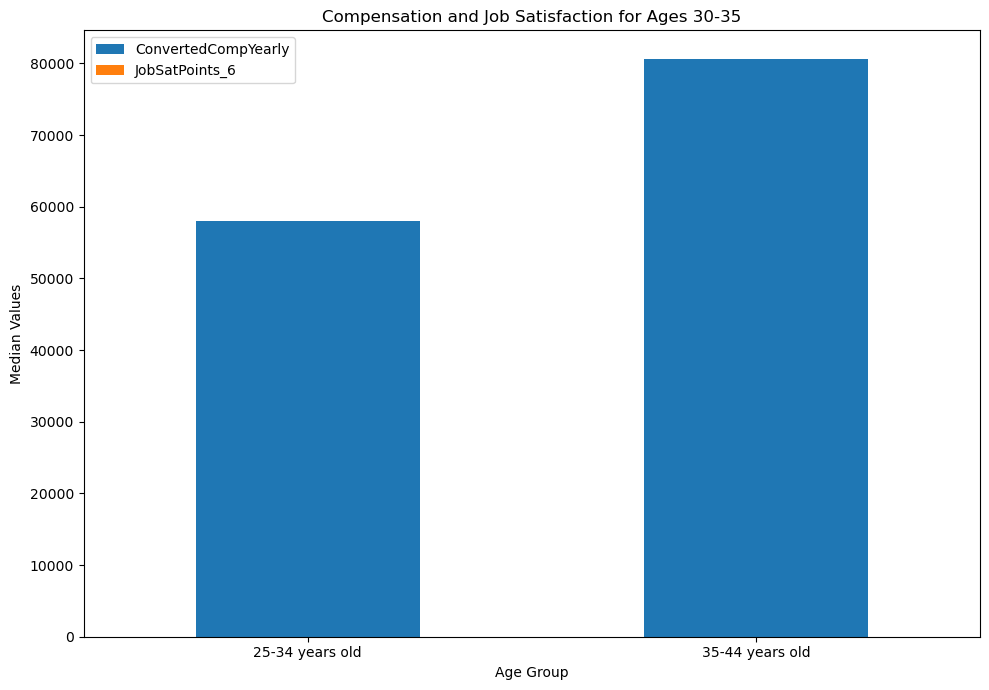

In [19]:
# Create stacked bar chart

stacked_data.plot(
    kind='bar',
    stacked=True,
    figsize=(10,7)
)

plt.title('Compensation and Job Satisfaction for Ages 30-35')
plt.xlabel('Age Group')
plt.ylabel('Median Values')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group

Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.

In [20]:
# Select required columns

age_comp_df = df[
    ['Age', 'ConvertedCompYearly', 'JobSatPoints_6']
].dropna()

# Display first few rows
print(age_comp_df.head())

                 Age  ConvertedCompYearly  JobSatPoints_6
72   18-24 years old               7322.0            65.0
379  35-44 years old              91295.0             0.0
389  25-34 years old             110000.0            20.0
392  35-44 years old             161044.0            30.0
398  45-54 years old             195000.0            30.0


In [21]:
# Convert columns to numeric

age_comp_df['ConvertedCompYearly'] = pd.to_numeric(
    age_comp_df['ConvertedCompYearly'],
    errors='coerce'
)

age_comp_df['JobSatPoints_6'] = pd.to_numeric(
    age_comp_df['JobSatPoints_6'],
    errors='coerce'
)

# Remove missing values
age_comp_df = age_comp_df.dropna()

In [22]:
# Remove extreme compensation outliers

upper_limit = age_comp_df['ConvertedCompYearly'].quantile(0.95)

age_comp_df = age_comp_df[
    age_comp_df['ConvertedCompYearly'] <= upper_limit
]

In [23]:
# Calculate median compensation and job satisfaction by age group

age_grouped = (
    age_comp_df
    .groupby('Age')[
        ['ConvertedCompYearly', 'JobSatPoints_6']
    ]
    .median()
)

print(age_grouped)

                    ConvertedCompYearly  JobSatPoints_6
Age                                                    
18-24 years old                 25359.0            20.0
25-34 years old                 57999.0            20.0
35-44 years old                 80555.0            20.0
45-54 years old                 93616.5            20.0
55-64 years old                107406.0            20.0
65 years or older              110000.0            25.0
Prefer not to say              126047.0            10.0
Under 18 years old               8661.0            10.0


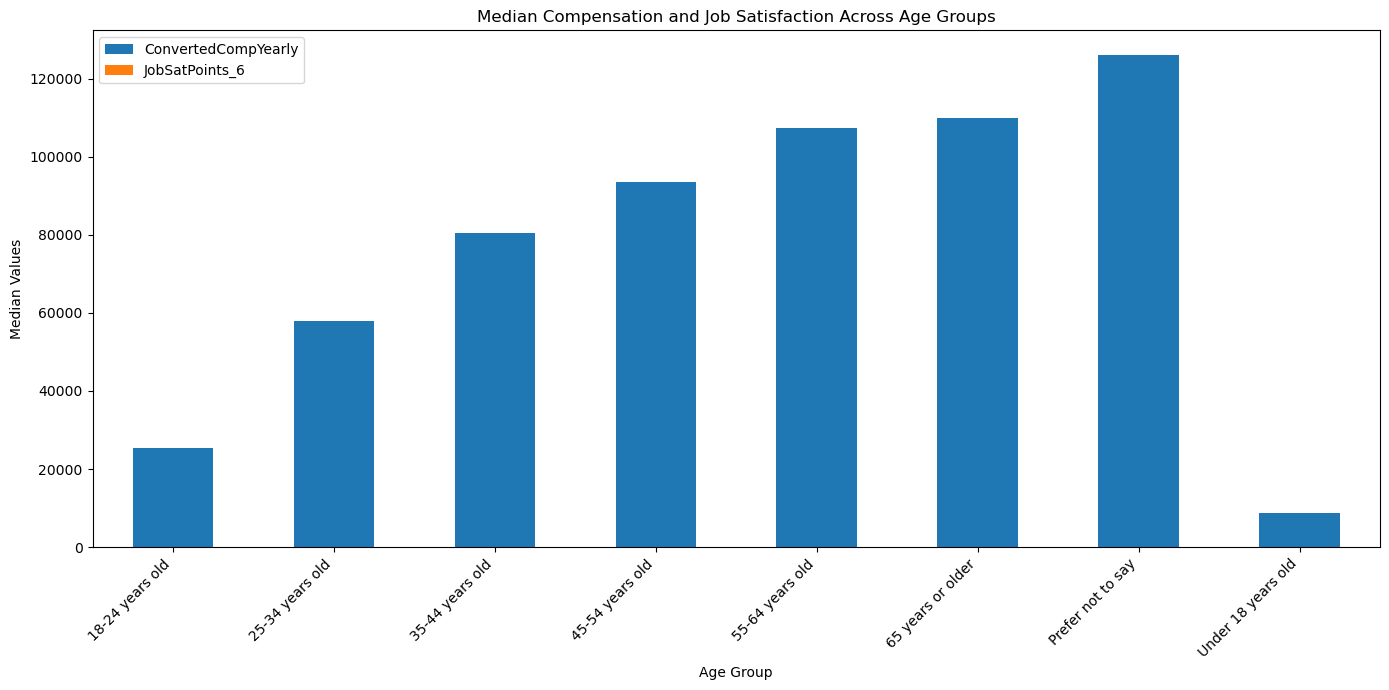

In [24]:
# Create stacked bar chart

age_grouped.plot(
    kind='bar',
    stacked=True,
    figsize=(14,7)
)

plt.title('Median Compensation and Job Satisfaction Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Median Values')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Stacked Charts

##### 1. Stacked Chart of Preferred Databases by Age Group

Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.

In [25]:
# Select required columns

db_age_df = df[
    ['Age', 'DatabaseWantToWorkWith']
].dropna()

# Display first few rows
print(db_age_df.head())

                  Age      DatabaseWantToWorkWith
1     35-44 years old                  PostgreSQL
2     45-54 years old  Firebase Realtime Database
3     18-24 years old    MongoDB;MySQL;PostgreSQL
4     18-24 years old           PostgreSQL;SQLite
5  Under 18 years old             Cloud Firestore


In [26]:
# Split multiple databases into separate rows

db_exploded = db_age_df.assign(
    DatabaseWantToWorkWith=
    db_age_df['DatabaseWantToWorkWith'].str.split(';')
).explode('DatabaseWantToWorkWith')

In [27]:
# Find top 5 desired databases

top_databases = (
    db_exploded['DatabaseWantToWorkWith']
    .value_counts()
    .head(5)
    .index
)

print(top_databases)

Index(['PostgreSQL', 'SQLite', 'MySQL', 'MongoDB', 'Redis'], dtype='object', name='DatabaseWantToWorkWith')


In [28]:
# Filter only top databases

filtered_df = db_exploded[
    db_exploded['DatabaseWantToWorkWith'].isin(top_databases)
].copy()

In [29]:
# Create pivot table for stacked chart

db_age_counts = (
    filtered_df
    .groupby(['Age', 'DatabaseWantToWorkWith'])
    .size()
    .unstack(fill_value=0)
)

print(db_age_counts.head())

DatabaseWantToWorkWith  MongoDB  MySQL  PostgreSQL  Redis  SQLite
Age                                                              
18-24 years old            3027   3077        5113   2235    3052
25-34 years old            4363   4465        9523   4542    4897
35-44 years old            2140   2536        5769   2779    3060
45-54 years old             773   1125        2201    865    1293
55-64 years old             234    471         724    176     493


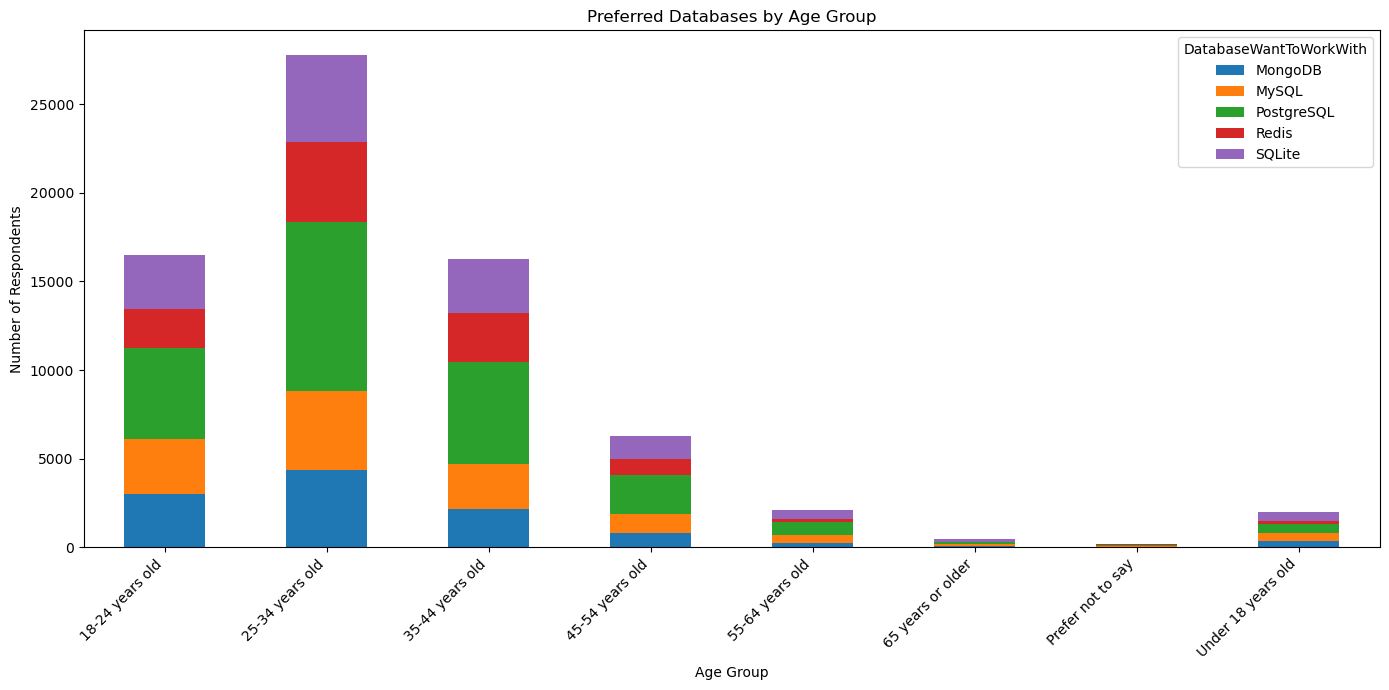

In [30]:
# Create stacked bar chart

db_age_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(14,7)
)

plt.title('Preferred Databases by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Respondents')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction

Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.

In [31]:
# Select required columns

employment_df = df[
    ['Employment', 'JobSat']
].dropna()

# Display first few rows
print(employment_df.head())

             Employment  JobSat
10  Employed, full-time     8.0
12  Employed, full-time     8.0
15  Employed, full-time     5.0
18  Employed, full-time    10.0
20  Employed, full-time     6.0


In [32]:
# Convert JobSat to numeric

employment_df['JobSat'] = pd.to_numeric(
    employment_df['JobSat'],
    errors='coerce'
)

# Remove missing values
employment_df = employment_df.dropna()

In [33]:
# Convert JobSat into integer categories

employment_df['JobSat'] = (
    employment_df['JobSat']
    .round()
    .astype(int)
)

print(employment_df['JobSat'].unique())

[ 8  5 10  6  9  4  7  3  2  1  0]


In [34]:
# Select top 5 employment types for readability

top_employment = (
    employment_df['Employment']
    .value_counts()
    .head(5)
    .index
)

filtered_df = employment_df[
    employment_df['Employment'].isin(top_employment)
].copy()

In [35]:
# Create pivot table for stacked chart

employment_satisfaction = (
    filtered_df
    .groupby(['JobSat', 'Employment'])
    .size()
    .unstack(fill_value=0)
)

print(employment_satisfaction.head())

Employment  Employed, full-time  \
JobSat                            
0                           242   
1                           209   
2                           599   
3                           900   
4                           848   

Employment  Employed, full-time;Independent contractor, freelancer, or self-employed  \
JobSat                                                                                 
0                                                          18                          
1                                                          18                          
2                                                          53                          
3                                                          74                          
4                                                          92                          

Employment  Employed, full-time;Student, part-time  Employed, part-time  \
JobSat                                                        

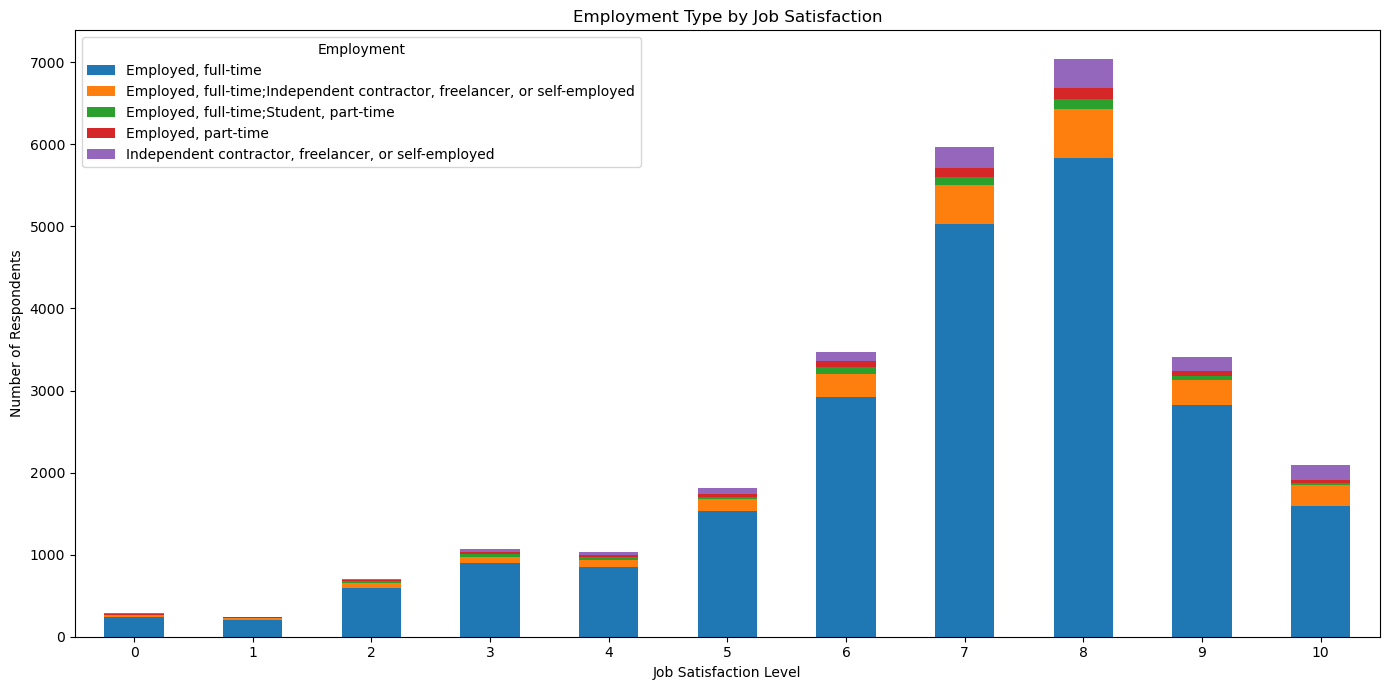

In [36]:
# Create stacked bar chart

employment_satisfaction.plot(
    kind='bar',
    stacked=True,
    figsize=(14,7)
)

plt.title('Employment Type by Job Satisfaction')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Number of Respondents')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts

##### 1. Stacked Chart for Preferred Programming Languages by Age Group

Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.

In [37]:
# Select required columns

lang_df = df[
    ['Age', 'LanguageAdmired']
].dropna()

# Display first few rows
print(lang_df.head())

                  Age                                    LanguageAdmired
1     35-44 years old  Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...
2     45-54 years old                                                 C#
3     18-24 years old  HTML/CSS;Java;JavaScript;PowerShell;Python;SQL...
4     18-24 years old                 C++;HTML/CSS;JavaScript;Lua;Python
5  Under 18 years old  Bash/Shell (all shells);HTML/CSS;Java;JavaScri...


In [38]:
# Split multiple admired languages into separate rows

lang_exploded = lang_df.assign(
    LanguageAdmired=
    lang_df['LanguageAdmired'].str.split(';')
).explode('LanguageAdmired')

In [39]:
# Find top 5 admired programming languages

top_languages = (
    lang_exploded['LanguageAdmired']
    .value_counts()
    .head(5)
    .index
)

print(top_languages)

Index(['JavaScript', 'Python', 'SQL', 'HTML/CSS', 'TypeScript'], dtype='object', name='LanguageAdmired')


In [40]:
# Filter only top admired languages

filtered_df = lang_exploded[
    lang_exploded['LanguageAdmired'].isin(top_languages)
].copy()

In [41]:
# Create pivot table for stacked chart

language_age_counts = (
    filtered_df
    .groupby(['Age', 'LanguageAdmired'])
    .size()
    .unstack(fill_value=0)
)

print(language_age_counts.head())

LanguageAdmired  HTML/CSS  JavaScript  Python   SQL  TypeScript
Age                                                            
18-24 years old      4523        4728    5157  4004        3567
25-34 years old      6937        7936    7431  7516        6696
35-44 years old      4580        5161    4239  5055        3766
45-54 years old      1800        2051    1802  2382        1146
55-64 years old       715         819     741  1028         320


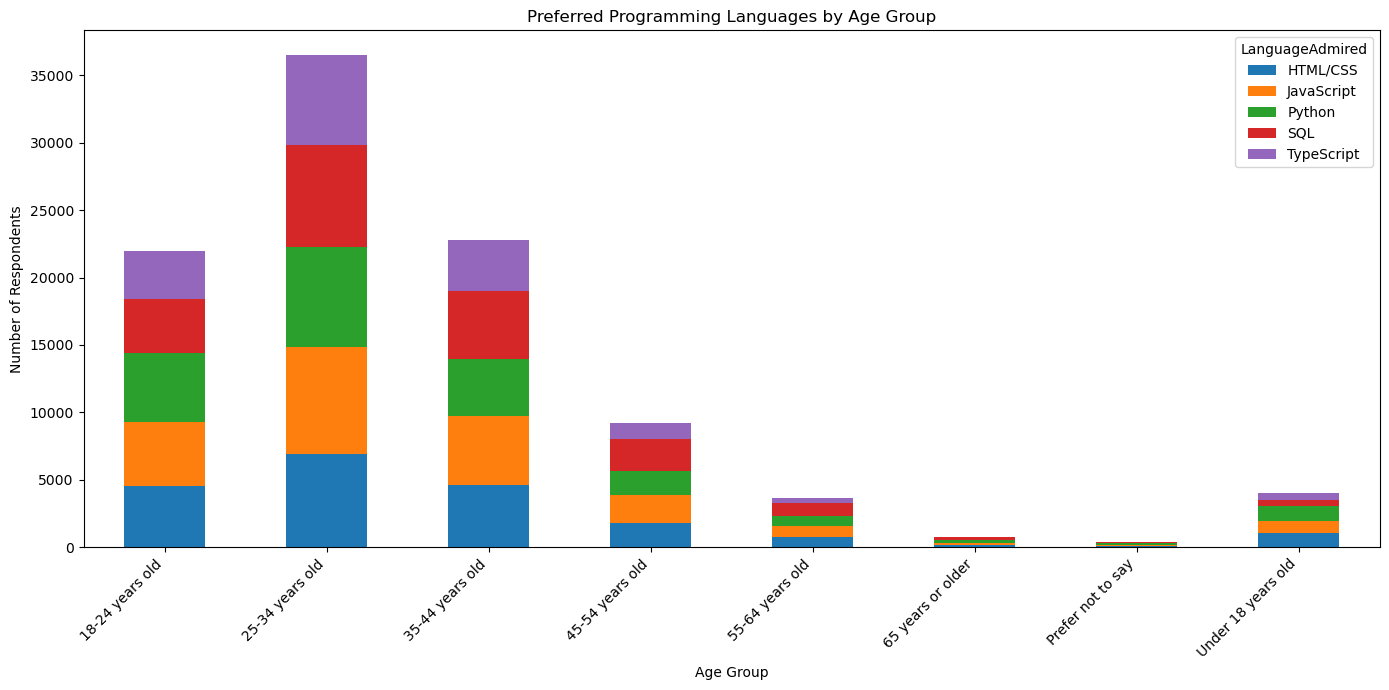

In [42]:
# Create stacked bar chart

language_age_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(14,7)
)

plt.title('Preferred Programming Languages by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Respondents')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type

Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)

In [43]:
# Select required columns

platform_df = df[
    ['Employment', 'PlatformAdmired']
].dropna()

# Display first few rows
print(platform_df.head())

                                          Employment  \
1                                Employed, full-time   
2                                Employed, full-time   
3                                 Student, full-time   
5                                 Student, full-time   
7  Student, full-time;Not employed, but looking f...   

                            PlatformAdmired  
1  Amazon Web Services (AWS);Heroku;Netlify  
2                              Google Cloud  
3                 Amazon Web Services (AWS)  
5                                Cloudflare  
7                                    Vercel  


In [44]:
# Split multiple admired platforms into separate rows

platform_exploded = platform_df.assign(
    PlatformAdmired=
    platform_df['PlatformAdmired'].str.split(';')
).explode('PlatformAdmired')

In [45]:
# Find top 5 admired platforms

top_platforms = (
    platform_exploded['PlatformAdmired']
    .value_counts()
    .head(5)
    .index
)

print(top_platforms)

Index(['Amazon Web Services (AWS)', 'Microsoft Azure', 'Google Cloud',
       'Cloudflare', 'Firebase'],
      dtype='object', name='PlatformAdmired')


In [46]:
# Select top employment types for readability

top_employment = (
    platform_exploded['Employment']
    .value_counts()
    .head(5)
    .index
)

# Filter dataset

filtered_df = platform_exploded[
    (platform_exploded['PlatformAdmired'].isin(top_platforms)) &
    (platform_exploded['Employment'].isin(top_employment))
].copy()

In [47]:
# Create pivot table for stacked chart

platform_employment_counts = (
    filtered_df
    .groupby(['Employment', 'PlatformAdmired'])
    .size()
    .unstack(fill_value=0)
)

print(platform_employment_counts.head())

PlatformAdmired                                     Amazon Web Services (AWS)  \
Employment                                                                      
Employed, full-time                                                      9584   
Employed, full-time;Independent contractor, fre...                       1144   
Independent contractor, freelancer, or self-emp...                       1106   
Not employed, but looking for work                                        410   
Student, full-time                                                        271   

PlatformAdmired                                     Cloudflare  Firebase  \
Employment                                                                 
Employed, full-time                                       2326      1713   
Employed, full-time;Independent contractor, fre...         492       367   
Independent contractor, freelancer, or self-emp...         519       333   
Not employed, but looking for work                  

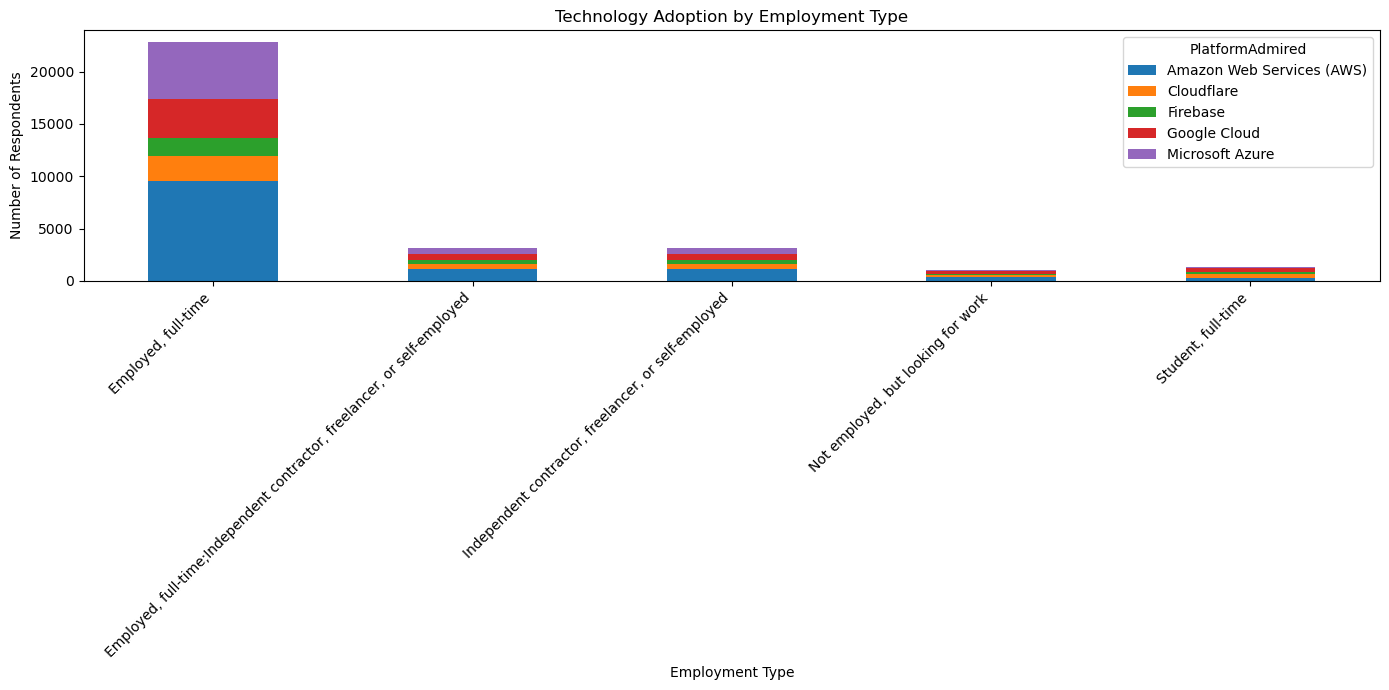

In [48]:
# Create stacked bar chart

platform_employment_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(14,7)
)

plt.title('Technology Adoption by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Number of Respondents')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Final Step: Review

In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.

## Summary

After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.